# Producing the inputs for the decay-angle study

`mulj_decay_angle.ipynb` next to this file reads one merged `.coffea` per sample.  This
notebook is where those come from.

It has two halves.  The first runs here, on two files of one signal sample and two of one
data sample, and its outputs are committed: they are the evidence that the recipe below
works, not a physics result.  The second half is the full campaign, 193,770 files over 152
samples, which does not run in a notebook; it is written out as the exact commands that
produced the inputs the study uses.

Nothing here is specific to one working copy: the sample lists, the submit files and the
job-argument generator are all in the repository.

In [1]:
import os
import sys

from coffea import processor
import coffea.util

# the repository root, whether the notebook was started here or from the root
_repo = os.getcwd().split("/sidm")[0]
if _repo not in sys.path:
    sys.path.insert(1, _repo)

from sidm.tools import llpnanoaodschema, sidm_processor, utilities

utilities.set_plot_style()
%matplotlib inline

print("repository root:", _repo)

repository root: /uscms_data/d3/murtazas/SIDM-wt-muljangle


## Configuration

The channels and histogram collections below are the ones the campaign ran, copied from
`condor/submit_mulj_*.sub`.  Data is processed in the five regions the study compares;
simulation adds the two signal channels, their signal-region variants and their variants
without the muon momentum cut, which are kept for cross-checks.

Two histogram collections are filled.  `mulj_decay_angle` holds everything the study draws;
`mulj_decay_angle_gen` holds the generator-level angle and is filled for simulation only,
since there is nothing to fill it from in data.

The campaign ran with **unweighted histograms**: no cross-section or generator weight is
applied at fill time.  The study normalises to unit area and applies the luminosity times
cross-section factor itself where it needs one, so do not change this without reading
caveat 5 of `README.md`.

In [2]:
# regions the study compares; data is processed in these five
CH_DATA = [
    "data_control_region_1muLj",
    "data_control_region_1muLj_cosmic_veto",
    "data_control_region_1muLj_spread_cosAlpha_mu_veto",
    "test_VR_2mu2e_invDisplaced_spread_cosAlpha_mu_veto",
    "test_VR_4mu_invDisplaced_spread_cosAlpha_mu_veto",
]

# simulation adds the signal channels and their variants
CH_MC = CH_DATA + [
    "4mu", "2mu2e",
    "4mu_sr", "2mu2e_sr",
    "4mu_noMuPtCut", "2mu2e_noMuPtCut",
]

COLLECTIONS_MC = ["mulj_decay_angle", "mulj_decay_angle_gen"]
COLLECTIONS_DATA = ["mulj_decay_angle"]

NTUPLE_VERSION = "llpNanoAOD_v2"
UNWEIGHTED_HIST = True

# one location config per category, as the submit files pass them
LOCATION_CFG = {
    "signal_4mu": "signal_4mu_v10.yaml",
    "signal_2mu2e": "signal_2mu2e_v10.yaml",
    "background": "backgrounds.yaml",
    "data": "data_skimmed.yaml",
}

print(f"{len(CH_DATA)} data channels, {len(CH_MC)} simulation channels")

5 data channels, 11 simulation channels


In [3]:
def read_sample_list(name):
    """The committed sample list of one campaign category."""
    path = os.path.join(_repo, "condor", f"mulj_{name}_samples.txt")
    with open(path, encoding="utf-8") as handle:
        return [line.strip() for line in handle
                if line.strip() and not line.startswith("#")]


SAMPLES = {name: read_sample_list(name) for name in
           ("signal_4mu", "signal_2mu2e", "background", "data")}

for name, samples in SAMPLES.items():
    print(f"{name:<13} {len(samples):>3} samples   e.g. {samples[0]}")
print(f"{'total':<13} {sum(len(s) for s in SAMPLES.values()):>3} samples")

signal_4mu     33 samples   e.g. 4Mu_100GeV_0p25GeV_0p02mm
signal_2mu2e   33 samples   e.g. 2Mu2E_100GeV_0p25GeV_0p02mm
background     18 samples   e.g. DYJetsToLL_M10to50
data           68 samples   e.g. DoubleMuon_2018A_0
total         152 samples


## 1. A run that fits in a notebook

Two files of one signal sample and two of one data sample, processed here with coffea's
iterative executor.  This is the same processor, the same channels and the same collections
the campaign uses; only the number of files differs.

`replace_xcache=True` is required on the LPC.  The location configs address files as
`root://xcache//...`, which resolves on coffea-casa and nowhere else; the flag rewrites
them to `root://cmseos.fnal.gov//...`.

The two cells below print a wall of warnings, one per chunk, and all of them are expected.
`Unable to apply ... for nested dsaMuons collection` is a cut that does not apply to
displaced-standalone muons; the `genMus`, `genEs`, `genAs` and `cannot fill counter` lines
are the generator-level collections, absent from data by definition; `Signal not in xs cfg,
assuming 1fb` is the missing cross section for this signal point, which does not matter
here because the histograms are unweighted and the study normalises to unit area anyway.
The other processing notebooks in this repository print the same set.

In [4]:
SIGNAL_SAMPLE = "4Mu_500GeV_1p2GeV_1p9mm"
DATA_SAMPLE = "DoubleMuon_2018A_0"
MAX_FILES = 2

runner = processor.Runner(
    # status=False: the progress widget does not survive into a saved notebook
    executor=processor.IterativeExecutor(status=False),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    chunksize=50_000,
    skipbadfiles=True,
)

print("signal:", SIGNAL_SAMPLE, "  data:", DATA_SAMPLE, f"  {MAX_FILES} files each")

signal: 4Mu_500GeV_1p2GeV_1p9mm   data: DoubleMuon_2018A_0   2 files each


In [5]:
fileset_signal = utilities.make_fileset(
    [SIGNAL_SAMPLE], NTUPLE_VERSION, max_files=MAX_FILES,
    location_cfg=LOCATION_CFG["signal_4mu"], replace_xcache=True)

processor_mc = sidm_processor.SidmProcessor(
    CH_MC, COLLECTIONS_MC, unweighted_hist=UNWEIGHTED_HIST)

output_signal = runner.run(fileset_signal, treename="Events",
                           processor_instance=processor_mc)
print("signal done")

Output()

Output()

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: 
RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: 
RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/awkward/_nplikes/array_module.py:292: 
RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))

...

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

4Mu_500GeV_1p2GeV_1p9mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
signal done


In [6]:
fileset_data = utilities.make_fileset(
    [DATA_SAMPLE], NTUPLE_VERSION, max_files=MAX_FILES,
    location_cfg=LOCATION_CFG["data"], replace_xcache=True)

processor_data = sidm_processor.SidmProcessor(
    CH_DATA, COLLECTIONS_DATA, unweighted_hist=UNWEIGHTED_HIST)

output_data = runner.run(fileset_data, treename="Events",
                         processor_instance=processor_data)
print("data done")

Output()

Output()

Applying 2018 Golden JSON: 0 events removed

Warning: weight not found in this sample. Skipping.

Warning: gens not found in this sample. Skipping.

...

Warning: cannot fill counter Gen As to muons. Skipping.

Warning: cannot fill counter Gen As to electrons. Skipping.

Warning: cannot fill counter Matched gen As to muons. Skipping.

Warning: cannot fill counter Matched gen As to electrons. Skipping.

DoubleMuon_2018A_0 is data. Not scaling histograms or cutflows.
data done


### Saving

One file per sample, named after the sample, which is what the merge step produces at full
scale and what the study's `INPUT_DIR` expects.  Here they go to a scratch directory rather
than into the repository.

In [7]:
OUT_DIR = os.path.join(os.path.expanduser("~"), "mulj_demo_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

for sample, output in ((SIGNAL_SAMPLE, output_signal), (DATA_SAMPLE, output_data)):
    path = os.path.join(OUT_DIR, f"{sample}.coffea")
    coffea.util.save(output["out"][sample], path)
    print(f"wrote {path}  ({os.path.getsize(path) / 1e3:.0f} kB)")

wrote /uscms/home/murtazas/mulj_demo_outputs/4Mu_500GeV_1p2GeV_1p9mm.coffea  (155 kB)
wrote /uscms/home/murtazas/mulj_demo_outputs/DoubleMuon_2018A_0.coffea  (35 kB)


### One histogram, as a sanity check

The decay angle of the signal sample in its own channel.  Two files is far too little for
physics; the point is that the axis exists, is filled, and covers zero to one.

8366 muon-lepton-jet pairs in the 4mu channel of 2 files


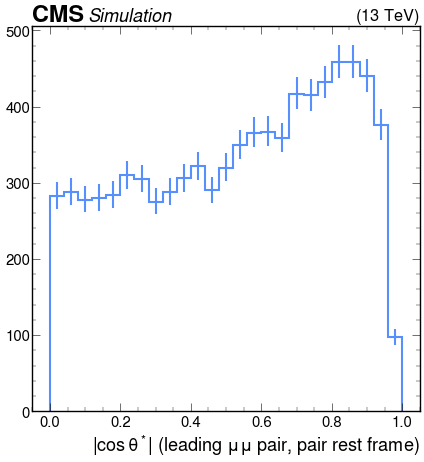

In [8]:
histogram = output_signal["out"][SIGNAL_SAMPLE]["hists"]["mu_lj_mumu_absCosTheta"]
utilities.plot(histogram["4mu", :], flow="none", yerr=True, density=False, linewidth=3)

entries = histogram["4mu", :].values().sum()
print(f"{entries:.0f} muon-lepton-jet pairs in the 4mu channel of {MAX_FILES} files")

## 2. The full campaign

Neither route below runs in this notebook: the code blocks are shown as commands to copy,
not as cells.  The campaign the study uses was produced by the second route.

### Route (a): Dask, from a notebook

Good for one category or a re-run of a handful of samples.  `scaleout.make_lpc_client`
starts an `lpcjobqueue` cluster and ships the working copy to the workers.  Watch the
memory of the notebook kernel itself, not only the workers.

```python
from sidm.tools import scaleout

client = scaleout.make_lpc_client(min_workers=10, max_workers=100, memory="4GB")

runner = processor.Runner(
    executor=processor.DaskExecutor(client=client),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    chunksize=50_000,
    skipbadfiles=True,
)

fileset = utilities.make_fileset(
    SAMPLES["signal_4mu"], NTUPLE_VERSION, max_files=-1,
    location_cfg=LOCATION_CFG["signal_4mu"], replace_xcache=True)

output = runner.run(fileset, treename="Events", processor_instance=processor_mc)
coffea.util.save(output["out"], "signal_4mu.coffea")
```

### Route (b): Condor, which is what produced the study's inputs

Three steps: generate the file lists and job arguments, submit, merge.  All three tools are
in the repository, as are the sample lists and the submit files.

The job arguments are generated, not stored.  One call per category, from the repository
root with the environment sourced:

```bash
cd <repository root>
source /uscms_data/d3/murtazas/SIDM/sidm_venv/bin/activate

python condor/make_job_args.py --samples-file condor/mulj_signal_4mu_samples.txt \
  --location-cfg signal_4mu_v10.yaml --files-per-job 5 --replace-xcache \
  --outdir condor/filelists_mulj_signal --job-args condor/job_args_mulj_signal_4mu.txt

python condor/make_job_args.py --samples-file condor/mulj_signal_2mu2e_samples.txt \
  --location-cfg signal_2mu2e_v10.yaml --files-per-job 5 --replace-xcache \
  --outdir condor/filelists_mulj_signal --job-args condor/job_args_mulj_signal_2mu2e.txt

python condor/make_job_args.py --samples-file condor/mulj_background_samples.txt \
  --location-cfg backgrounds.yaml --files-per-job 30 --replace-xcache \
  --outdir condor/filelists_mulj_bkg --job-args condor/job_args_mulj_bkg.txt

python condor/make_job_args.py --samples-file condor/mulj_data_samples.txt \
  --location-cfg data_skimmed.yaml --files-per-job 30 --replace-xcache \
  --outdir condor/filelists_mulj_data --job-args condor/job_args_mulj_data.txt
```

That chunking gives 701, 2,109 and 4,278 jobs over 152 samples and 193,770 files.  Submit
from inside `condor/`, with the proxy on shared NFS rather than in `/tmp`, which the schedd
cannot read.  The channel lists and collections of the configuration cell above are baked
into the three submit files, so they do not have to be passed again:

```bash
cd condor
export X509_USER_PROXY=/uscms_data/d3/murtazas/x509_proxy.pem
condor_submit submit_mulj_signal.sub    #   701 jobs
condor_submit submit_mulj_bkg.sub       # 2,109 jobs
condor_submit submit_mulj_data.sub      # 4,278 jobs
```

A drained queue is not success.  Read the exit-code histogram and count the chunks on EOS,
then reconcile each cluster against what it should have produced:

```bash
python condor/condor_campaign.py reconcile \
  --job-args condor/job_args_mulj_data.txt \
  --logs-dir condor/logs_mulj_data \
  --eos-chunk-dir /store/user/<user>/sidm_condor/MuljDecayAngle_Run2018_v1 \
  --run-id mulj_data_v1
```

Finally merge the chunks into one file per sample.  All three categories write into the same
EOS directory and sample names are unique across them, so one pass covers everything.  The
chunks were produced unweighted, so the merge has to be told:

```bash
python sidm/scripts/merge_coffea_chunks_eos.py \
  --input-eos-dir  /store/user/<user>/sidm_condor/MuljDecayAngle_Run2018_v1 \
  --output-eos-dir /store/group/lpcmetx/SIDM/coffea_outputs/<user>/mulj_decay_angle \
  --unweighted-hist \
  --filelists-dir condor/filelists_mulj_data \
  --hist-collections mulj_decay_angle,mulj_decay_angle_gen
```

### What the study expects

One merged `.coffea` per sample, all in one directory, named after the sample.  Point
`INPUT_DIR` in `mulj_decay_angle.ipynb` at it, either as a local path or as a
`root://` URL, and set `LUMI_FB`.  The sample lists there are read from whatever is present
in the directory, so nothing else has to be edited.